**Author:** Biswajit Jana
**Date:** February 25, 2026

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/exoplanet-archive/2026-07-30-habitable-zone-trappist1/notebook.ipynb)

# Which TRAPPIST-1 planets actually sit in the habitable zone?

**Learning goals** -- after this notebook you will be able to:
- Pull real stellar (Teff, luminosity) and planetary (semi-major axis) parameters for the TRAPPIST-1 system from the NASA Exoplanet Archive.
- Compute habitable-zone (HZ, the range of distances from a star where a rocky planet could sustain liquid surface water) boundaries using the Kopparapu et al. (2013) empirical formulation, and cross-check with the simpler inverse-square-law approximation.
- Place every real planet in the system on a distance-from-star diagram against the computed HZ boundaries.
- Read a results table showing, for each planet, its semi-major axis (the average planet-star distance, in AU, over one orbit), whether it falls inside or outside the computed HZ, and by how much.

**Background.** The habitable zone is the shell of orbital distances around a star where a planet with an Earth-like atmosphere could maintain liquid water on its surface -- too close and a runaway greenhouse boils it away, too far and it freezes out. The HZ boundaries depend on the star's luminosity (total light output, in units of the Sun's luminosity) and, more precisely, on its effective temperature (Teff, the surface temperature that sets its spectrum), because redder/cooler stars shift the location of the relevant radiative feedbacks. Kopparapu et al. (2013) fit polynomial corrections to the simple inverse-square-law estimate using detailed radiative-convective climate models; we use their "runaway greenhouse" (inner) and "maximum greenhouse" (outer) conservative limits.

## 1. Pull real system parameters from the archive

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyvo as vo

svc = vo.dal.TAPService('https://exoplanetarchive.ipac.caltech.edu/TAP')
query = '''
SELECT pl_name, pl_orbsmax, pl_orbsmaxerr1, pl_rade, st_teff, st_lum, st_rad, st_mass
FROM pscomppars
WHERE hostname = 'TRAPPIST-1'
'''
tab = svc.search(query).to_table()
sys_df = tab.to_table().to_pandas() if hasattr(tab,'to_table') else tab.to_pandas()
sys_df = sys_df.dropna(subset=['pl_orbsmax']).sort_values('pl_orbsmax').reset_index(drop=True)
print(f"{len(sys_df)} planets with a measured semi-major axis in TRAPPIST-1")
sys_df

7 planets with a measured semi-major axis in TRAPPIST-1


,pl_name,pl_orbsmax,pl_orbsmaxerr1,pl_rade,st_teff,st_lum,st_rad,st_mass
0,TRAPPIST-1 b,0.01154,0.00010,1.116,2566.0,-3.25727,0.1192,0.0898
1,TRAPPIST-1 c,0.01580,0.00013,1.097,2566.0,-3.25727,0.1192,0.0898
2,TRAPPIST-1 d,0.02227,0.00019,0.788,2566.0,-3.25727,0.1192,0.0898
3,TRAPPIST-1 e,0.02925,0.00250,0.920,2566.0,-3.25727,0.1192,0.0898
4,TRAPPIST-1 f,0.03849,0.00033,1.045,2566.0,-3.25727,0.1192,0.0898
5,TRAPPIST-1 g,0.04683,0.00040,1.129,2566.0,-3.25727,0.1192,0.0898
6,TRAPPIST-1 h,0.06189,0.00053,0.755,2566.0,-3.25727,0.1192,0.0898


## 2. Compute the habitable-zone boundaries

**Simple inverse-square-law estimate** (using stellar luminosity L in solar units):

HZ_inner ~ sqrt(L / 1.1) AU,  HZ_outer ~ sqrt(L / 0.53) AU

**Kopparapu et al. (2013) empirical fit** (more accurate, accounts for stellar temperature):

Seff = Seff_sun + a*T + b*T^2 + c*T^3 + d*T^4, with T = Teff - 5780 K

d_boundary = sqrt(L / Seff) AU

We use the *Runaway Greenhouse* coefficients for the conservative inner edge and *Maximum Greenhouse* for the conservative outer edge (Kopparapu et al. 2013, Table 3). The Kopparapu fit is calibrated for Teff in 2600-7200 K; we flag if the host star falls outside that range.

In [2]:
# Kopparapu et al. 2013, Table 3 coefficients (conservative HZ)
KOP = {
    'runaway_greenhouse':   dict(Seff=1.107, a=1.332e-4, b=1.580e-8, c=-8.308e-12, d=-1.931e-15),
    'maximum_greenhouse':   dict(Seff=0.356, a=6.171e-5, b=1.698e-9, c=-3.198e-12, d=-5.575e-16),
}

def kopparapu_seff(teff, coeffs):
    T = teff - 5780.0
    return coeffs['Seff'] + coeffs['a']*T + coeffs['b']*T**2 + coeffs['c']*T**3 + coeffs['d']*T**4

teff = sys_df.st_teff.iloc[0]
lum_log = sys_df.st_lum.iloc[0]   # archive reports log10(L/Lsun)
L = 10**lum_log

in_valid_range = 2600 <= teff <= 7200
print(f"Host star Teff = {teff:.0f} K  (Kopparapu fit valid 2600-7200 K: {'yes' if in_valid_range else 'NO -- extrapolating beyond calibration range'})")
print(f"Host star luminosity L = {L:.5f} Lsun  (log10 L = {lum_log:.3f})")

# inverse-square-law estimate
hz_inner_isq = np.sqrt(L / 1.1)
hz_outer_isq = np.sqrt(L / 0.53)
print(f"\nInverse-square-law HZ: {hz_inner_isq:.4f} -- {hz_outer_isq:.4f} AU")

# Kopparapu estimate
seff_inner = kopparapu_seff(teff, KOP['runaway_greenhouse'])
seff_outer = kopparapu_seff(teff, KOP['maximum_greenhouse'])
hz_inner_kop = np.sqrt(L / seff_inner)
hz_outer_kop = np.sqrt(L / seff_outer)
print(f"Kopparapu (2013) conservative HZ: {hz_inner_kop:.4f} -- {hz_outer_kop:.4f} AU")

Host star Teff = 2566 K  (Kopparapu fit valid 2600-7200 K: NO -- extrapolating beyond calibration range)
Host star luminosity L = 0.00055 Lsun  (log10 L = -3.257)

Inverse-square-law HZ: 0.0224 -- 0.0323 AU
Kopparapu (2013) conservative HZ: 0.0246 -- 0.0499 AU


## 3. Place every real planet against the computed boundaries

In [3]:
rows = []
for _, p in sys_df.iterrows():
    a = p.pl_orbsmax
    if a < hz_inner_kop:
        status = 'inside (too close / hot)' if a >= hz_inner_kop*0 and a < hz_inner_kop else 'inside'
        status = 'INSIDE inner edge (too hot)'
        margin = hz_inner_kop - a
    elif a > hz_outer_kop:
        status = 'OUTSIDE outer edge (too cold)'
        margin = a - hz_outer_kop
    else:
        status = 'WITHIN habitable zone'
        margin = min(a - hz_inner_kop, hz_outer_kop - a)
    rows.append({'planet': p.pl_name, 'a_AU': round(a,4), 'status': status, 'margin_AU': round(margin,4)})

hz_table = pd.DataFrame(rows)
hz_table

,planet,a_AU,status,margin_AU
0,TRAPPIST-1 b,0.0115,INSIDE inner edge (too hot),0.0131
1,TRAPPIST-1 c,0.0158,INSIDE inner edge (too hot),0.0088
2,TRAPPIST-1 d,0.0223,INSIDE inner edge (too hot),0.0024
3,TRAPPIST-1 e,0.0293,WITHIN habitable zone,0.0046
4,TRAPPIST-1 f,0.0385,WITHIN habitable zone,0.0114
5,TRAPPIST-1 g,0.0468,WITHIN habitable zone,0.0031
6,TRAPPIST-1 h,0.0619,OUTSIDE outer edge (too cold),0.0120


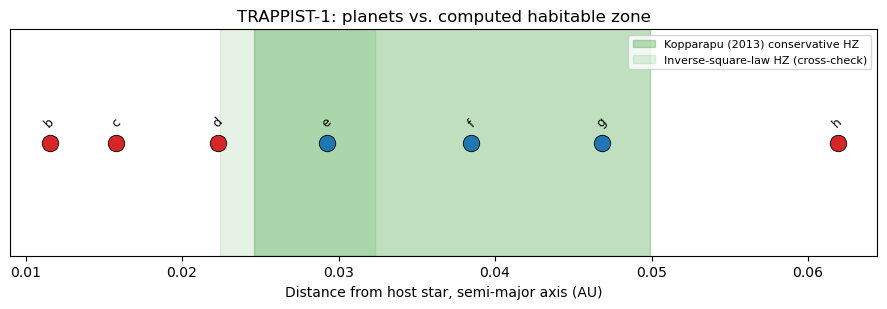

In [4]:
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.axvspan(hz_inner_kop, hz_outer_kop, color='green', alpha=0.25, label='Kopparapu (2013) conservative HZ')
ax.axvspan(hz_inner_isq, hz_outer_isq, color='green', alpha=0.10, label='Inverse-square-law HZ (cross-check)')

for _, p in sys_df.iterrows():
    in_hz = hz_inner_kop <= p.pl_orbsmax <= hz_outer_kop
    ax.scatter(p.pl_orbsmax, 0, s=140, color='tab:blue' if in_hz else 'tab:red', zorder=5,
               edgecolor='k', linewidth=0.6)
    ax.annotate(p.pl_name.replace(sys_df.pl_name.iloc[0].split()[0]+' ', ''), (p.pl_orbsmax, 0),
                xytext=(0, 12), textcoords='offset points', ha='center', fontsize=9, rotation=45)

ax.set_yticks([])
ax.set_xlabel('Distance from host star, semi-major axis (AU)')
ax.set_title('TRAPPIST-1: planets vs. computed habitable zone')
ax.legend(loc='upper right', fontsize=8)
fig.tight_layout()
fig.savefig('habitable_zone.png', dpi=150)
plt.show()

## What I'd look at next

- Redo the calculation with the *optimistic* HZ boundaries (Recent Venus / Early Mars coefficients from Kopparapu et al. 2013) to see how many additional planets get counted as potentially habitable under a more permissive definition.
- Propagate the reported uncertainty on semi-major axis (`pl_orbsmaxerr1`) into the inside/outside classification, since several planets sit close to the computed boundary and a 1-sigma shift could flip their status.
- For Trappist-1's outer planets, cross-check the archive's `st_teff` against an independent spectroscopic temperature, since the Kopparapu fit is sensitive to Teff and, for very cool M dwarfs like TRAPPIST-1, the calibration is being extrapolated below its nominal validity range.

**Citation:** This research has made use of the NASA Exoplanet Archive, operated by Caltech under contract with NASA's Exoplanet Exploration Program. https://exoplanetarchive.ipac.caltech.edu/docs/counts_detail.html

Habitable-zone formulation: Kopparapu, R. K., et al. 2013, ApJ, 765, 131, "Habitable Zones around Main-sequence Stars: New Estimates" (https://doi.org/10.1088/0004-637X/765/2/131).